# 02 · Section 2.1: build and understand the spherical quantum box
### Companion to Pietryga et al., journal pp. 10515–10517, equations (1)–(8)

[First complete the foundations notebook](https://colab.research.google.com/github/Shlok-Joseph-Paul/physical-modeling-intuition/blob/main/klimov_section2/01_foundations.ipynb) if wavefunctions, holes, or effective mass are new.

**Goal:** Explain Figure 1 and every equation in §2.1; make numerical predictions; identify the model's assumptions and limits.
Work in two or three sittings of about 35–50 minutes, adjusting the pace to your understanding.

Save a copy in Drive, then **Runtime → Run all**. This notebook runs independently of Notebook 01.
Write a prediction before changing each control. Code is supplied.
In Colab, controls appear above each plot. Run the cell once; changes then rerun it automatically. Press ▶ if needed. Saved plots are previews, and GitHub does not run controls.
Write your conclusions in the text cells so your saved copy retains them.

Keep the paper beside you. We use its notation where possible and explicitly translate units.
The illustrations are newly drawn model calculations; no experimental data are used here.

**Updated edition:** Section 3 now derives the box wavefunction step by step. Controls use native Colab forms. If you saved an earlier Drive copy, reopen this GitHub-linked edition and make a new copy; existing Drive copies do not automatically receive these edits.

In [1]:
# @title Start the lesson (run once; a CPU runtime is enough)
import importlib.util
import subprocess
import sys
needed = {'numpy': 'numpy>=1.24', 'scipy': 'scipy>=1.10',
          'matplotlib': 'matplotlib>=3.7', 'ipywidgets': 'ipywidgets>=8.0'}
missing = [spec for module, spec in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
try:
    from google.colab import output
    IN_COLAB=True
except ImportError:
    IN_COLAB=False
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from scipy.special import spherical_jn
from scipy.optimize import brentq
from scipy.integrate import quad
from functools import lru_cache
import ipywidgets as W
from IPython.display import display, HTML, clear_output
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 12})
BLUE, ORANGE, GREEN, GRAY = '#215f9a', '#b95524', '#267969', '#626977'
K = constants.hbar**2/(2*constants.m_e*constants.e)*1e18  # eV nm^2
C = constants.e/(4*np.pi*constants.epsilon_0)*1e9        # eV nm
HC = constants.h*constants.c/constants.e*1e9           # eV nm
A0 = constants.physical_constants['Bohr radius'][0]*1e9
LABS, QUIZZES = {}, {}

def slider(label, value, minimum, maximum, step):
    return W.FloatSlider(description=label, value=value, min=minimum, max=maximum,
        step=step, continuous_update=False, readout_format='.2f',
        style={'description_width': '130px'}, layout=W.Layout(width='440px', max_width='100%'))

def lab(key, fn, controls, form_values=None):
    """Colab uses native form fields; Jupyter uses visible, live widgets."""
    if form_values is not None:
        for name,value in form_values.items():
            controls[name].value=value
    values={k:w.value for k,w in controls.items()}
    if IN_COLAB:
        LABS[key]=(fn,controls,None)
        display(HTML('<p><b>Colab controls are above the plot.</b> Run this cell once; subsequent control changes rerun it automatically. If needed, press ▶ again.</p>'))
        fn(**values)
    else:
        live=W.interactive_output(fn,controls)
        LABS[key]=(fn,controls,live)
        display(W.VBox([*controls.values(),live]))
        display(HTML('<p><b>Saved preview.</b> In Colab, use the form controls at the top of this cell and run it. In Jupyter, use the live controls above.</p>'))
        fn(**values)

def quiz(key, prompt, choices, correct, explanations, form_answer='Choose an answer'):
    if IN_COLAB:
        display(HTML('<p><b>'+prompt+'</b></p>'))
        if form_answer not in choices:
            display(HTML('<p>Choose your answer in the form above. Run once to enable automatic feedback.</p>'))
        else:
            i=choices.index(form_answer)
            prefix='Correct. ' if i==correct else 'Try again. '
            display(HTML('<p><b>'+prefix+'</b>'+explanations[i]+'</p>'))
        return
    select=W.RadioButtons(options=[('Choose an answer',-1)]+[(s,i) for i,s in enumerate(choices)],
                          value=-1,layout=W.Layout(width='100%'))
    button=W.Button(description='Check reasoning',button_style='info')
    result=W.HTML()
    def check(_):
        i=select.value
        if i<0: result.value='<p>Choose an answer first.</p>'
        else:
            prefix='Correct. ' if i==correct else 'Try again. '
            result.value='<p><b>'+prefix+'</b>'+explanations[i]+'</p>'
    button.on_click(check)
    QUIZZES[key]=(select,button,result,check,correct,explanations)
    display(W.VBox([W.HTML('<b>'+prompt+'</b>'),select,button,result]))

print('Ready. Colab: controls are built into each experiment. Run a cell once, then change its controls; press ▶ if it does not refresh.')

Ready. Colab: controls are built into each experiment. Run a cell once, then change its controls; press ▶ if it does not refresh.


In [2]:
# @title Spherical-box model (run once; no code edits needed)
@lru_cache(maxsize=None)
def root(n, ell):
    """Nth strictly positive zero of spherical j_ell; n >= 1, ell >= 0."""
    if n<1 or ell<0: raise ValueError('Need n >= 1 and ell >= 0.')
    if ell==0: return n*np.pi
    grid=np.linspace(.001,(n+ell+3)*np.pi,4000)
    values=spherical_jn(ell,grid)
    brackets=np.flatnonzero(values[:-1]*values[1:]<0)
    if len(brackets)<n: raise ValueError('Root search interval too short.')
    j=brackets[n-1]
    return brentq(lambda x:spherical_jn(ell,x),grid[j],grid[j+1],xtol=1e-13)

def energy(n,ell,R,mass_ratio):
    return K*root(n,ell)**2/(mass_ratio*np.asarray(R)**2)

def radial(s,n,ell):
    # Dimensionless R^(3/2) times the normalized radial envelope.
    a=root(n,ell)
    return np.sqrt(2)*spherical_jn(ell,a*np.asarray(s))/abs(spherical_jn(ell+1,a))

def radial_prob(s,n=1,ell=0):
    s=np.asarray(s)
    return s*s*radial(s,n,ell)**2  # normalized w.r.t. ds

def pair_terms(R,me=.13,mh=.78,eps=6.,eg=1.75,coefficient=1.765):
    electron=energy(1,0,R,me);hole=energy(1,0,R,mh)
    attraction=-coefficient*C/(eps*np.asarray(R))
    return electron,hole,attraction,eg+electron+hole+attraction

def bohr_radius(me,mh,eps):
    mu=me*mh/(me+mh)
    return A0*eps/mu

STATES={'1S':(1,0),'1P':(1,1),'1D':(1,2),'2S':(2,0)}
print('Model ready. R is always radius in nm. Mass controls are m*/m₀.')

Model ready. R is always radius in nm. Mass controls are m*/m₀.


## 1 · State the model before trusting the formula

A spherical quantum dot has radius $R$. Inside, the envelope experiences a constant potential; outside, an infinite barrier.
We treat a carrier as having a constant, isotropic effective mass $m^*$.

This combines five assumptions:

1. The envelope varies slowly enough relative to the lattice for the effective-mass approximation.
2. The relevant bulk band is approximately parabolic, so kinetic energy is $\hbar^2k^2/(2m^*)$.
3. Coupling to other bands is neglected: the single-band approximation.
4. The boundary is a perfect sphere with an infinite barrier; there is no leakage.
5. Electron and hole are first solved independently; their attraction is then added as a small correction.

The plotted wavefunctions are **envelopes**, not full atom-by-atom crystal wavefunctions.
Electron spin is omitted from the spatial solution. Real dots need not satisfy all these assumptions equally well.

### A notation card

- **$R$:** Dot radius; $D=2R$ is diameter
- **$r,\theta,\phi$:** Distance from centre, polar angle, azimuthal angle
- **$n=1,2,\ldots$:** Radial solution number within a fixed angular family
- **$L=0,1,2,\ldots$:** Envelope orbital-angular-momentum number: S, P, D, …
- **$M=-L,\ldots,L$:** Projection quantum number along a chosen axis
- **$m^*$:** Effective mass; unrelated to $M$
- **$\varphi_{n,L}$:** Dimensionless Bessel zero; unrelated to azimuth $\phi$
- **$\Phi$:** Envelope wavefunction
- **$E_{g,0}$:** Bulk band gap
- **$\epsilon_\infty$:** High-frequency relative dielectric constant in our SI formulas

Angular momentum is a quantum property with measurement values: the envelope has squared magnitude $L(L+1)\hbar^2$ and projection $M\hbar$.
It is not a claim that the electron follows a small circular orbit.
Later sections add spin and Bloch angular momentum; they are distinct from this envelope $L$.

## 2 · From a standing wave to a spherical standing wave — equation (1)

In 3D, write an allowed envelope as **radial shape × angular shape**:
$$\Phi_{nLM}(r,\theta,\phi)=
\sqrt{\frac{2}{R^3}}\,
\frac{j_L(\varphi_{n,L}r/R)}{|j_{L+1}(\varphi_{n,L})|}
\,Y_{LM}(\theta,\phi).$$

This is equation (1) with an absolute value in the normalization denominator. That only fixes an overall sign; it changes no probabilities.

- $j_L$ is a **spherical Bessel function**: the radial standing-wave shape appropriate to this geometry.
- $Y_{LM}$ is a **spherical harmonic**: the angular pattern. It is normalized over solid angle.
- The boundary requires $j_L(kR)=0$. Its allowed positive roots give $k_{n,L}=\varphi_{n,L}/R$.
- The prefactor ensures total probability one: $\int|\Phi|^2\,d^3r=1$.

**Dimensional check:** $\varphi_{n,L}$ is a pure number; $k$ has units of inverse length. When Figure 1 labels roots, interpret them as $kR$, not $k$ in physical units.

For $L=0$, $j_0(z)=\sin z/z$, with the continuous value $j_0(0)=1$.
The first root is $\pi$, then $2\pi$, etc. Other angular patterns have different roots.

**Predict:** If $kR$ is halfway between allowed roots, does the wave satisfy the wall? Does changing the effective mass move these roots?

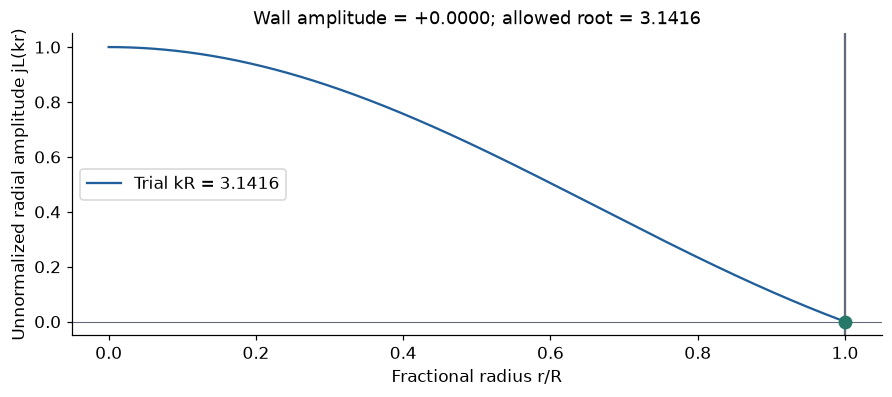

In [3]:
# @title Experiment 1 — find a radial wave that fits the wall {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
angular_family = 'S (L=0)' # @param ["S (L=0)", "P (L=1)", "D (L=2)"]
state_n = 1 # @param {"type": "slider", "min": 1, "max": 3, "step": 1}
offset_from_root = 0.0 # @param {"type": "slider", "min": -0.7, "max": 0.7, "step": 0.05}

def boundary_plot(ell=0,n=1,offset=0.):
    s=np.linspace(0,1,600)
    allowed=root(n,ell);q=allowed+offset
    shape=spherical_jn(ell,q*s)
    endpoint=float(spherical_jn(ell,q))
    fig,ax=plt.subplots(figsize=(8,3.5),layout='constrained')
    ax.plot(s,shape,color=BLUE,label=f'Trial kR = {q:.4f}')
    ax.axhline(0,color=GRAY,lw=.7);ax.axvline(1,color=GRAY)
    ax.scatter([1],[endpoint],s=65,color=GREEN if abs(endpoint)<1e-9 else ORANGE,zorder=4)
    ax.set(xlabel='Fractional radius r/R',ylabel='Unnormalized radial amplitude jL(kr)',
           title=f'Wall amplitude = {endpoint:+.4f}; allowed root = {allowed:.4f}')
    ax.legend()
    plt.show()
lab('boundary',boundary_plot,{
    'ell':W.Dropdown(description='Family L',options=[('S (L=0)',0),('P (L=1)',1),('D (L=2)',2)]),
    'n':W.IntSlider(description='Root n',value=1,min=1,max=3,continuous_update=False),
    'offset':slider('Offset from root',0,-.7,.7,.05)}, form_values={'ell': {'S (L=0)': 0, 'P (L=1)': 1, 'D (L=2)': 2}[angular_family], 'n': int(state_n), 'offset': offset_from_root})

**Try:** Start at zero offset. Move away from it. Switch S → P → D at $n=1$.

**My reasoning:** Quantization comes from ______. Mass does/does not move the roots because ______.

<details><summary>Reveal after predicting</summary>
Only the roots make the amplitude zero at the wall. Geometry and boundary conditions determine the dimensionless roots, independently of mass in this infinite-barrier model. Mass changes the energy assigned to each spatial solution.
</details>

### Where the radial equation comes from — a short derivation

Inside the sphere the 3D Schrödinger equation is
$$-\frac{\hbar^2}{2m^*}\nabla^2\Phi=E\Phi.$$
The symbol $\nabla^2$ is the three-dimensional curvature operator.
Writing $\Phi=f(r)Y_{LM}$ separates radial and angular variation:
$$\frac{1}{r^2}\frac{d}{dr}\left(r^2\frac{df}{dr}\right)
+\left[k^2-\frac{L(L+1)}{r^2}\right]f=0.$$
Its regular solution is $f\propto j_L(kr)$; the second independent solution is singular at the centre and is excluded.

For S states, define $u(r)=r f(r)$. Then $u''+k^2u=0$.
Regularity requires $u(0)=0$, and the wall gives $u(R)=0$.
So $u\propto\sin(n\pi r/R)$ and $f\propto\sin(n\pi r/R)/r$.

You do not need to derive special functions from scratch. You should be able to explain which equation they solve, why one solution is excluded, and why the wall selects roots.

## 3 · Read the level ladder — equation (2) and Figure 1

Substituting $k=\varphi_{n,L}/R$ gives
$$E_{n,L}=\frac{\hbar^2\varphi_{n,L}^2}{2m^*R^2}.$$
These are positive confinement energies measured away from the relevant bulk band edge.

| State | (n, L) | Dimensionless root | Spatial degeneracy (2L+1) |
|---|---|---|---|
| 1S | (1,0) | π ≈ 3.142 | 1 |
| 1P | (1,1) | 4.493 | 3 |
| 1D | (1,2) | 5.763 | 5 |
| 2S | (2,0) | 2π ≈ 6.283 | 1 |

**Degenerate** means distinct states share an energy. In this sphere energy is independent of $M$.
Spin would provide another factor of two for a simple spin-degenerate electron level; it is not included in the table.
The label 2S means the second S radial solution, not the second-lowest state overall and not a hydrogen principal quantum number.

The useful numerical form is
$$E_{n,L}\;(\mathrm{eV})=
\frac{0.03809982\ \mathrm{eV\,nm^2}}{(m^*/m_0)R^2\;(\mathrm{nm^2})}\,\varphi_{n,L}^2.$$

**Predict:** At equal radius, which carrier has more widely separated levels: an electron of mass $0.13m_0$ or a hole of mass $0.78m_0$?

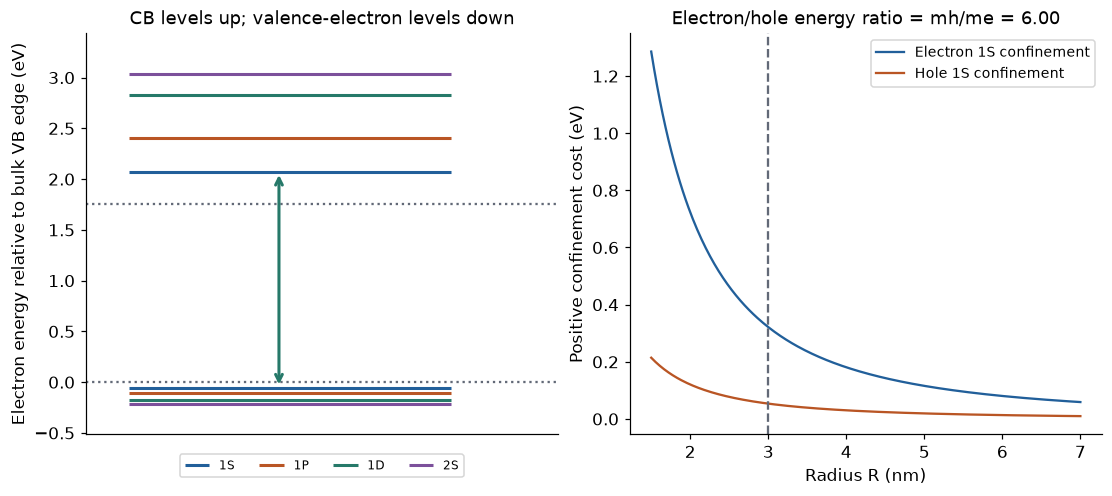

In [4]:
# @title Experiment 2 — electron and hole ladders {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
radius_nm = 3.0 # @param {"type": "slider", "min": 1.5, "max": 7.0, "step": 0.25}
electron_mass_ratio = 0.13 # @param {"type": "slider", "min": 0.05, "max": 0.5, "step": 0.01}
hole_mass_ratio = 0.78 # @param {"type": "slider", "min": 0.2, "max": 1.2, "step": 0.02}

def ladder_plot(R=3.,me=.13,mh=.78):
    eg=1.75
    fig,ax=plt.subplots(1,2,figsize=(10,4.4),layout='constrained')
    maxe=energy(2,0,R,me);maxh=energy(2,0,R,mh)
    ax[0].axhline(eg,color=GRAY,ls=':');ax[0].axhline(0,color=GRAY,ls=':')
    for (name,(n,ell)),colour in zip(STATES.items(),[BLUE,ORANGE,GREEN,'#7c509b']):
        ee=energy(n,ell,R,me);eh=energy(n,ell,R,mh)
        ax[0].hlines(eg+ee,.1,.85,color=colour,lw=2,label=name)
        
        ax[0].hlines(-eh,.1,.85,color=colour,lw=2)
        
    ax[0].annotate('',xy=(.45,eg+energy(1,0,R,me)),xytext=(.45,-energy(1,0,R,mh)),
                   arrowprops=dict(arrowstyle='<->',color=GREEN,lw=2))
    ax[0].set(xlim=(0,1.1),xticks=[],ylim=(-maxh-.3,eg+maxe+.4),
              ylabel='Electron energy relative to bulk VB edge (eV)',
              title='CB levels up; valence-electron levels down')
    ax[0].legend(loc='upper center',bbox_to_anchor=(.5,-.035),ncol=4,fontsize=8)
    rr=np.linspace(1.5,7,300)
    ax[1].plot(rr,energy(1,0,rr,me),color=BLUE,label='Electron 1S confinement')
    ax[1].plot(rr,energy(1,0,rr,mh),color=ORANGE,label='Hole 1S confinement')
    ax[1].axvline(R,color=GRAY,ls='--')
    ax[1].set(xlabel='Radius R (nm)',ylabel='Positive confinement cost (eV)',
              title=f'Electron/hole energy ratio = mh/me = {mh/me:.2f}')
    ax[1].legend(fontsize=9)
    plt.show()
lab('ladder',ladder_plot,{'R':slider('Radius R (nm)',3,1.5,7,.25),
                       'me':slider('Electron m*/m₀',.13,.05,.5,.01),
                       'mh':slider('Hole m*/m₀',.78,.2,1.2,.02)}, form_values={'R': radius_nm, 'me': electron_mass_ratio, 'mh': hole_mass_ratio})

**Try:** Double $R$ from 2 to 4 nm. Then keep $R$ fixed and double one mass.

**My reasoning:** The electron ladder is more spread out because ______.
The arrow in the left panel spans ______, before including attraction.

The numerical defaults are **illustrative CdSe-like values**: bulk gap 1.75 eV, $m_e=0.13m_0$, $m_h=0.78m_0$, $\epsilon_\infty=6$.
The paper gives a CdSe hole/electron mass ratio of about six; we choose masses with that ratio.
This is not a fitted CdSe parameter set. Actual hole masses are more complicated, as §2.3 explains.

### See the angular patterns behind S, P, and D

S is spherically symmetric. P and D have angular structure as well as radial structure.
The colours in the signed view mark positive and negative **amplitude**, not electric charge.
The density view removes the sign by taking the squared magnitude.

For the P family, Pz is the $M=0$ state. Px is a real combination of the $M=\pm1$ states; it is not a new energy.
Rotating within this degenerate family changes the angular pattern without changing the energy in the ideal sphere.
The Dz² view is the $L=2,M=0$ state. The 2S state instead introduces a radial node.

**Predict:** Will switching 1S → 2S introduce an angular nodal plane, a radial nodal surface, or both?

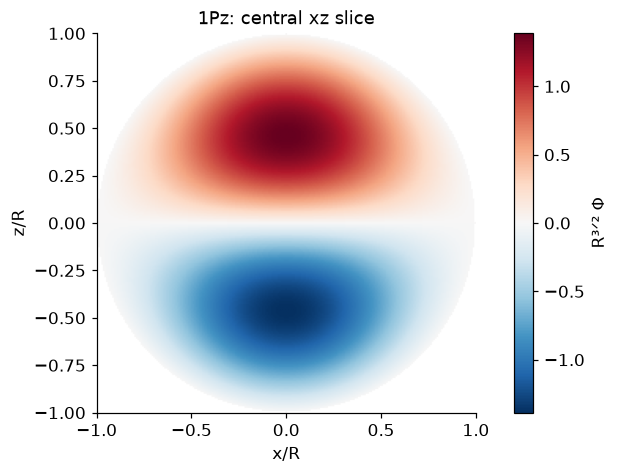

These are central slices, not the probability integrated along the viewing direction.


In [5]:
# @title Experiment — signed angular patterns and probability slices {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
state = '1Pz' # @param ["1S", "1Pz", "1Px", "1Dz²", "2S"]
view = 'Signed amplitude' # @param ["Signed amplitude", "Probability density"]

def angular_slice(state='1Pz',view='Signed amplitude'):
    t=np.linspace(-1,1,241);x,z=np.meshgrid(t,t);s=np.sqrt(x*x+z*z)
    cosz=np.divide(z,s,out=np.zeros_like(s),where=s>0)
    cosx=np.divide(x,s,out=np.zeros_like(s),where=s>0)
    if state in ['1S','2S']:
        n,ell=(1 if state=='1S' else 2),0
        angular=np.ones_like(s)/np.sqrt(4*np.pi)
    elif state in ['1Pz','1Px']:
        n,ell=1,1
        angular=np.sqrt(3/(4*np.pi))*(cosz if state=='1Pz' else cosx)
    else:
        n,ell=1,2
        angular=np.sqrt(5/(16*np.pi))*(3*cosz**2-1)
    amplitude=radial(s,n,ell)*angular
    values=amplitude if view=='Signed amplitude' else amplitude**2
    masked=np.ma.masked_where(s>1,values)
    vmax=float(np.max(np.abs(masked)))
    fig,ax=plt.subplots(figsize=(5.8,4.2),layout='constrained')
    im=ax.imshow(masked,origin='lower',extent=(-1,1,-1,1),
                 cmap='RdBu_r' if view=='Signed amplitude' else 'Blues',
                 vmin=-vmax if view=='Signed amplitude' else 0,vmax=vmax)
    ax.set(xlabel='x/R',ylabel='z/R',title=f'{state}: central xz slice')
    fig.colorbar(im,ax=ax,label='R³ᐟ² Φ' if view=='Signed amplitude' else 'R³ |Φ|²')
    plt.show()
    print('These are central slices, not the probability integrated along the viewing direction.')
lab('angular',angular_slice,{
    'state':W.Dropdown(description='State',options=['1S','1Pz','1Px','1Dz²','2S'],value='1Pz'),
    'view':W.Dropdown(description='View',options=['Signed amplitude','Probability density'])}, form_values={'state': {'1S': '1S', '1Pz': '1Pz', '1Px': '1Px', '1Dz²': '1Dz²', '2S': '2S'}[state], 'view': {'Signed amplitude': 'Signed amplitude', 'Probability density': 'Probability density'}[view]})

**My reasoning:** In 2S the new node is ______. Switching 1Pz to 1Px changes ______ but leaves ______ unchanged.

## 4 · Where is the particle? — equations (3) and (4)

For the ground state, $n=1,L=0,M=0$ and $Y_{00}=1/\sqrt{4\pi}$.
The normalized full envelope becomes
$$\Phi_{100}(r)=\frac{1}{\sqrt{2\pi R}}\frac{\sin(\pi r/R)}{r}.$$
This is equation (3). At $r=0$ take the limit $\sin(\pi r/R)/r\to\pi/R$:
the amplitude is finite, not infinite.

The energy is
$$E_{1,0}=\frac{\hbar^2\pi^2}{2m^*R^2},$$
which is equation (4).

There are two different probability questions:

- **Equal tiny volumes:** compare local density $|\Phi(r)|^2$ in units of inverse volume.
- **Entire thin spherical shells:** compare $P_r(r)=4\pi r^2|\Phi(r)|^2$ in units of inverse length, for this S state.

A shell at larger radius contains more volume. The centre has maximal local density in 1S, but an infinitesimal shell at the centre has vanishing volume.
For 1S,
$$P_r(r)=\frac{2}{R}\sin^2(\pi r/R),\qquad \int_0^R P_r(r)\,dr=1.$$

**Predict:** Does maximal local density at the centre mean most measurements have radius near zero?

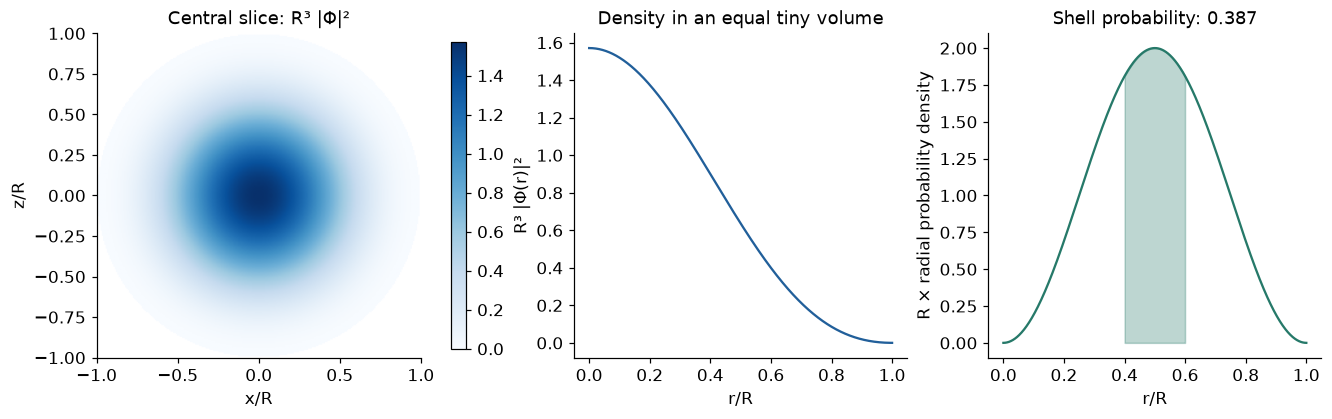

Physical shell: 1.20–1.80 nm. Centre density: 0.0582 nm⁻³.
The curves use scaled units; doubling R divides local density by 8, not by 2.


In [6]:
# @title Experiment 3 — a point, a slice, and a shell are different questions {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
radius_nm = 3.0 # @param {"type": "slider", "min": 1.5, "max": 6.0, "step": 0.25}
shell_start = 0.4 # @param {"type": "slider", "min": 0.0, "max": 1.0, "step": 0.05}
shell_end = 0.6 # @param {"type": "slider", "min": 0.0, "max": 1.0, "step": 0.05}
# @markdown The two shell edges are sorted automatically.

def ground_plot(R=3.,shell=(.4,.6)):
    s=np.linspace(0,1,1000)
    # R^3 |Phi|^2: dimensionless local density; sinc handles the origin.
    rho_scaled=np.pi/2*np.sinc(s)**2
    t=np.linspace(-1,1,250);x,z=np.meshgrid(t,t);r=np.sqrt(x*x+z*z)
    density=np.ma.masked_where(r>1,np.pi/2*np.sinc(r)**2)
    a,b=shell
    probability=(b-a)-(np.sin(2*np.pi*b)-np.sin(2*np.pi*a))/(2*np.pi)
    fig,ax=plt.subplots(1,3,figsize=(12,3.7),layout='constrained')
    im=ax[0].imshow(density,origin='lower',extent=(-1,1,-1,1),cmap='Blues',vmin=0,vmax=np.pi/2)
    ax[0].set(xlabel='x/R',ylabel='z/R',title='Central slice: R³ |Φ|²')
    fig.colorbar(im,ax=ax[0],fraction=.046)
    ax[1].plot(s,rho_scaled,color=BLUE)
    ax[1].set(xlabel='r/R',ylabel='R³ |Φ(r)|²',title='Density in an equal tiny volume')
    p=2*np.sin(np.pi*s)**2
    ax[2].plot(s,p,color=GREEN)
    ax[2].fill_between(s,0,p,where=(s>=a)&(s<=b),color=GREEN,alpha=.3)
    ax[2].set(xlabel='r/R',ylabel='R × radial probability density',
              title=f'Shell probability: {probability:.3f}')
    plt.show()
    print(f'Physical shell: {a*R:.2f}–{b*R:.2f} nm. Centre density: {np.pi/(2*R**3):.4f} nm⁻³.')
    print('The curves use scaled units; doubling R divides local density by 8, not by 2.')
lab('ground',ground_plot,{'R':slider('Radius R (nm)',3,1.5,6,.25),
    'shell':W.FloatRangeSlider(description='Shell in r/R',value=(.4,.6),min=0,max=1,step=.05,continuous_update=False)}, form_values={'R': radius_nm, 'shell': tuple(sorted((shell_start, shell_end)))})

**Try:** Compare equal-width shells near the centre and near $r/R=0.5$. Then double the physical radius.

**My reasoning:** The most probable radius for 1S is ______. It differs from the maximum of local density because ______.
If the same fractional shell is selected in a larger dot, its probability ______.

<details><summary>Reveal the distinction</summary>
Radial probability density peaks at R/2, although local volume density peaks at the centre. Shell probability includes the volume factor 4πr². The same fractional shell has the same probability in the scaled ground state; physical local density falls as R⁻³.
</details>

In [7]:
# @title Checkpoint — degeneracy is not an extra particle {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
your_answer = "Choose an answer" # @param ["Choose an answer", "one electron must occupy all three states as three particles.", "three distinct angular states have the same energy.", "the P state has three radial nodes."]

quiz('degeneracy','The 1P spatial level is threefold degenerate. This means…',
     ['one electron must occupy all three states as three particles.',
      'three distinct angular states have the same energy.',
      'the P state has three radial nodes.'],1,
     ['Degeneracy counts available states, not the number of particles present.',
      'M can be −1, 0, or +1 for L = 1, and all three energies match in the ideal sphere.',
      'For the first radial root there are no interior radial nodes. The three is 2L+1.'], form_answer=your_answer)

## 5 · Add electron and hole confinement — equation (5)

The noninteracting band-edge separation is
$$E_g^{(0)}(R)=E_{g,0}+
\frac{\hbar^2\pi^2}{2m_eR^2}+
\frac{\hbar^2\pi^2}{2m_hR^2}.$$

The **reduced mass**
$$\mu=\frac{m_em_h}{m_e+m_h},\qquad \frac{1}{\mu}=\frac{1}{m_e}+\frac{1}{m_h}$$
lets us compress this to
$$E_g^{(0)}(R)=E_{g,0}+\frac{\hbar^2\pi^2}{2\mu R^2}.$$
The paper calls the reduced mass $m_{eh}$ and defines confinement energy as $E_c=E_g-E_{g,0}$ before attraction is added.
Here $E_c$ always means the positive sum of electron and hole confinement costs; we label the signed Coulomb term separately.

A smaller mass dominates the sum: if $m_h\gg m_e$, then $\mu\approx m_e$.
The reduced mass is less than either individual mass, not their average.

### Work one example before using the sliders

Take $R=3$ nm, $m_e/m_0=0.13$, $m_h/m_0=0.78$ and $E_{g,0}=1.75$ eV.
Then $\mu/m_0\approx0.1114$.

$$E_e=\frac{0.03809982\pi^2}{0.13\times 3^2}\approx0.3214\ {\rm eV},$$
$$E_h\approx0.0536\ {\rm eV},\quad E_c\approx0.3750\ {\rm eV}.$$
The noninteracting separation is about $2.1250$ eV.

**Predict:** If $R$ doubles, does $2.1250$ eV become one quarter as large?

## 6 · Add electron–hole attraction — equations (6), (7), and (8)

The electrostatic interaction is negative:
$$V_{eh}(\mathbf r_e,\mathbf r_h)=
-\frac{e^2}{4\pi\epsilon_0\epsilon_\infty|\mathbf r_e-\mathbf r_h|}.$$

This is equation (6) in **SI units**. The paper writes $-e^2/(\epsilon|\mathbf r_e-\mathbf r_h|)$ in its electrostatic convention.
Do not paste that expression into SI code and omit $4\pi\epsilon_0$.
Here $e$ is the positive elementary-charge magnitude, $\epsilon_0$ is vacuum permittivity, and $\epsilon_\infty$ is dimensionless.

**Screening:** polarization of the material reduces the effective interaction. Larger $\epsilon_\infty$ means weaker attraction.
The paper uses the high-frequency dielectric constant because the tightly confined motion is on an energy scale large compared with lattice vibrations; the slow lattice contribution should not be included in the same way.

We have already solved the box without attraction. **First-order perturbation theory** means calculating its mean interaction energy in those unperturbed states:
$$\Delta_{eh}=\langle \Phi_e\Phi_h|V_{eh}|\Phi_e\Phi_h\rangle$$
$$=\int d^3r_e\,d^3r_h\,
|\Phi_e(\mathbf r_e)|^2|\Phi_h(\mathbf r_h)|^2
V_{eh}(\mathbf r_e,\mathbf r_h).$$
This is equation (7). The bra–ket notation means an expectation value, or probability-weighted average. The two position integrals average over the independent unperturbed electron and hole densities; they do not set both particles at the same location.

Because those shapes scale with $r/R$, their mean inverse separation scales as $1/R$:
$$\Delta_{eh}=-c_{\rm eh}\frac{e^2}{4\pi\epsilon_0\epsilon_\infty R}.$$

Using the paper's printed coefficient $c_{\rm eh}=1.765$, equation (8) becomes
$$\boxed{E_{\rm pair}(R)\approx
E_{g,0}+\frac{\hbar^2\pi^2}{2\mu R^2}
-\frac{1.765e^2}{4\pi\epsilon_0\epsilon_\infty R}.}$$

The paper uses $E_g$ for the corrected quantity. We say **pair excitation energy** here to distinguish it from the noninteracting level separation and from a quasiparticle gap.

**Predict:** On shrinking $R$, both confinement and attraction get larger in magnitude. Which grows faster?

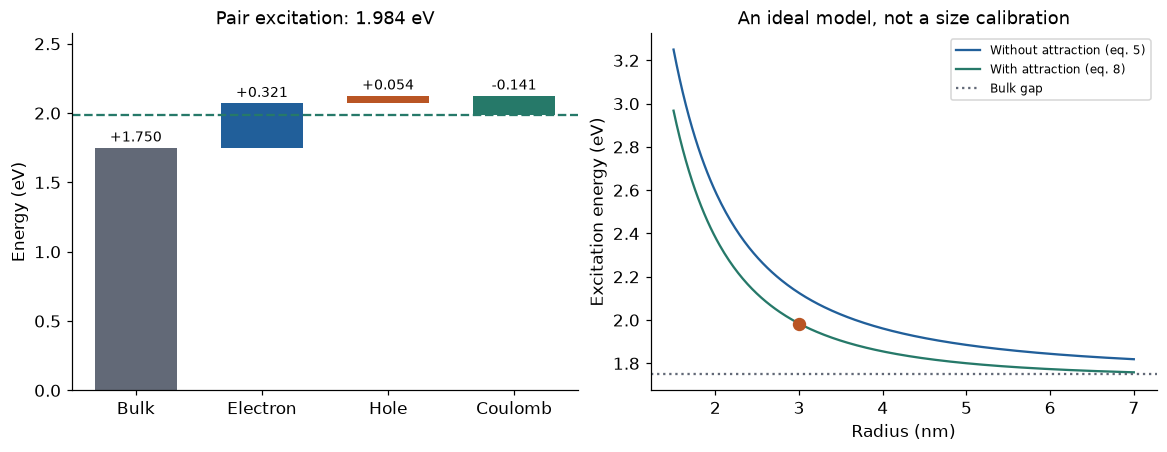

μ/m₀ = 0.1114; Ec = 0.3750 eV; signed Coulomb term = -0.1412 eV
Relative attraction |Δ|/Ec = 0.377; first-order treatment needs this much smaller than 1.
Equivalent photon wavelength = 625.0 nm (not an emission-spectrum prediction).


In [8]:
# @title Experiment 4 — separate every contribution to the pair energy {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
radius_nm = 3.0 # @param {"type": "slider", "min": 1.5, "max": 7.0, "step": 0.25}
electron_mass_ratio = 0.13 # @param {"type": "slider", "min": 0.05, "max": 0.5, "step": 0.01}
hole_mass_ratio = 0.78 # @param {"type": "slider", "min": 0.2, "max": 1.2, "step": 0.02}
dielectric_constant = 6.0 # @param {"type": "slider", "min": 3.0, "max": 12.0, "step": 0.5}
include_attraction = True # @param {"type": "boolean"}

def gap_plot(R=3.,me=.13,mh=.78,eps=6.,include_attraction=True):
    eg=1.75
    ee,eh,att,total=pair_terms(R,me,mh,eps,eg)
    if not include_attraction: att=0.;total=eg+ee+eh
    rr=np.linspace(1.5,7,300)
    e,h,a,t=pair_terms(rr,me,mh,eps,eg)
    fig,ax=plt.subplots(1,2,figsize=(10.5,4),layout='constrained')
    values=[eg,float(ee),float(eh),float(att)]
    bottom=0
    for i,(v,color) in enumerate(zip(values,[GRAY,BLUE,ORANGE,GREEN])):
        ax[0].bar(i,v,bottom=bottom,color=color,width=.65)
        ax[0].text(i,bottom+max(v,0)+.045,f'{v:+.3f}',ha='center',fontsize=9)
        bottom+=v
    ax[0].axhline(total,color=GREEN,ls='--')
    ax[0].set(xticks=range(4),xticklabels=['Bulk','Electron','Hole','Coulomb'],
              ylabel='Energy (eV)',ylim=(0,max(total,eg+ee+eh)+.45),
              title=f'Pair excitation: {total:.3f} eV')
    ax[1].plot(rr,eg+e+h,color=BLUE,label='Without attraction (eq. 5)')
    ax[1].plot(rr,t,color=GREEN,label='With attraction (eq. 8)')
    ax[1].axhline(eg,color=GRAY,ls=':',label='Bulk gap')
    ax[1].scatter([R],[total],color=ORANGE,s=60,zorder=4)
    ax[1].set(xlabel='Radius (nm)',ylabel='Excitation energy (eV)',
              title='An ideal model, not a size calibration')
    ax[1].legend(fontsize=8)
    plt.show()
    mu=me*mh/(me+mh)
    print(f'μ/m₀ = {mu:.4f}; Ec = {ee+eh:.4f} eV; signed Coulomb term = {att:.4f} eV')
    print(f'Relative attraction |Δ|/Ec = {abs(att)/(ee+eh):.3f}; first-order treatment needs this much smaller than 1.')
    print(f'Equivalent photon wavelength = {HC/total:.1f} nm (not an emission-spectrum prediction).')
lab('gap',gap_plot,{'R':slider('Radius R (nm)',3,1.5,7,.25),
                   'me':slider('Electron m*/m₀',.13,.05,.5,.01),
                   'mh':slider('Hole m*/m₀',.78,.2,1.2,.02),
                   'eps':slider('Dielectric ε∞',6,3,12,.5),
                   'include_attraction':W.Checkbox(description='Include attraction',value=True)}, form_values={'R': radius_nm, 'me': electron_mass_ratio, 'mh': hole_mass_ratio, 'eps': dielectric_constant, 'include_attraction': include_attraction})

**Try in order:**

1. At the defaults, verify the worked confinement calculation.
2. Switch attraction on: $\Delta_{eh}\approx-0.1412$ eV and $E_{\rm pair}\approx1.9838$ eV.
3. Change radius from 3 to 6 nm. Confinement becomes one quarter as large; attraction magnitude becomes one half.
4. Hold radius fixed and double the dielectric constant. Only the attraction term changes in this model.
5. Change the hole mass. Explain why an already heavy hole has less influence than the light electron.

**My reasoning:** Smaller dots have greater pair energy in the strong-confinement regime because ______.
The entire pair energy does not scale as $R^{-2}$ because ______.

## 7 · Know when the correction stops being small

A formula can return a number outside the conditions used to derive it.
Two useful diagnostics are
$$\eta=\frac{|\Delta_{eh}|}{E_c},\qquad
a_B^*=\frac{4\pi\epsilon_0\epsilon_\infty\hbar^2}{\mu e^2}
=a_0\frac{\epsilon_\infty}{\mu/m_0}.$$
$a_B^*$ is a hydrogen-like bulk exciton length estimated with the **same dielectric convention** as this model.
Different bulk-exciton contexts can require a different dielectric treatment.

- $R\ll a_B^*$ and small $\eta$ support the picture of confinement dominating attraction.
- These are **diagnostics**, not rigorous error bars or a universal pass/fail threshold.
- At large $R$, attraction becomes relatively more important; the uncorrelated box-pair picture ceases to describe the bulk exciton correctly.
- At very small $R$, the smooth-envelope, parabolic-band, and constant-mass assumptions become less reliable.
- Finite barriers allow leakage. Dielectric mismatch can add polarization/image-charge corrections. Both are absent here.
- Nonspherical shape, band mixing, exchange, spin, surfaces, and phonons require further physics.

Even though equation (8) approaches the bulk gap as $R\to\infty$, it does not recover a finite bulk exciton binding energy. That limiting behavior exposes the restricted regime of this approximation.

**Predict:** As radius increases, does the absolute attraction get smaller while its importance relative to confinement gets larger?

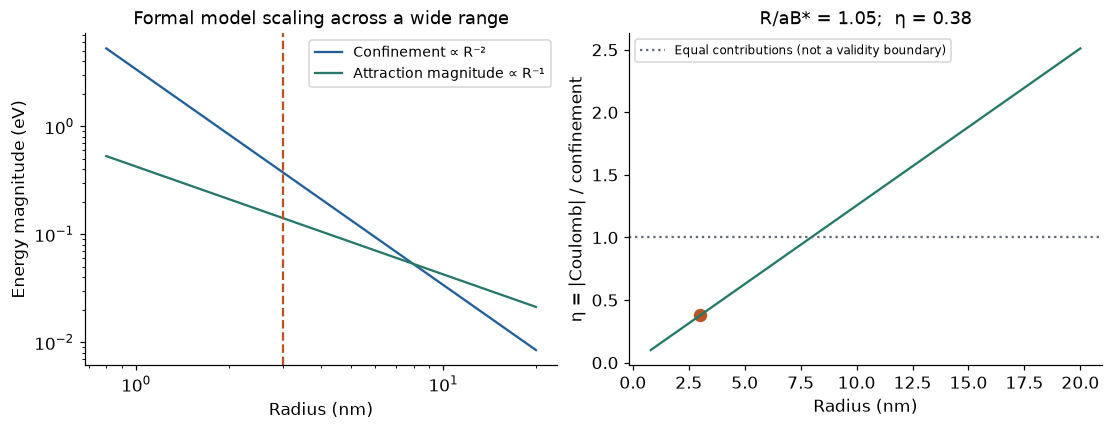

Estimated aB* = 2.85 nm. The plot explores the formula, not certified model accuracy.
If η is not small, first-order attraction is not a quantitatively controlled correction.


In [9]:
# @title Experiment 5 — see the model's competing scales {run: "auto", single-column: true}
# @markdown **Predict first.** Run this cell once, then change its controls. The plot/feedback will update automatically; press ▶ if it does not.
radius_nm = 3.0 # @param {"type": "slider", "min": 1.0, "max": 20.0, "step": 0.5}
dielectric_constant = 6.0 # @param {"type": "slider", "min": 3.0, "max": 12.0, "step": 0.5}

def regime_plot(R=3.,eps=6.):
    me,mh=.13,.78
    rr=np.linspace(.8,20,400)
    ee,eh,att,total=pair_terms(rr,me,mh,eps)
    selected=pair_terms(R,me,mh,eps)
    eta=abs(selected[2])/(selected[0]+selected[1])
    ab=bohr_radius(me,mh,eps)
    fig,ax=plt.subplots(1,2,figsize=(10,3.8),layout='constrained')
    ax[0].loglog(rr,ee+eh,color=BLUE,label='Confinement ∝ R⁻²')
    ax[0].loglog(rr,-att,color=GREEN,label='Attraction magnitude ∝ R⁻¹')
    ax[0].axvline(R,color=ORANGE,ls='--')
    ax[0].set(xlabel='Radius (nm)',ylabel='Energy magnitude (eV)',
              title='Formal model scaling across a wide range')
    ax[0].legend(fontsize=9)
    ax[1].plot(rr,-att/(ee+eh),color=GREEN)
    ax[1].axhline(1,color=GRAY,ls=':',label='Equal contributions (not a validity boundary)')
    ax[1].scatter([R],[eta],color=ORANGE,s=60)
    ax[1].set(xlabel='Radius (nm)',ylabel='η = |Coulomb| / confinement',
              title=f'R/aB* = {R/ab:.2f};  η = {eta:.2f}')
    ax[1].legend(fontsize=8)
    plt.show()
    print(f'Estimated aB* = {ab:.2f} nm. The plot explores the formula, not certified model accuracy.')
    print('If η is not small, first-order attraction is not a quantitatively controlled correction.')
lab('regime',regime_plot,{'R':slider('Radius R (nm)',3,1,20,.5),
                        'eps':slider('Dielectric ε∞',6,3,12,.5)}, form_values={'R': radius_nm, 'eps': dielectric_constant})

**My reasoning:** At large radius the approximation becomes questionable because ______.
At very small radius a different assumption becomes questionable: ______.

### Research habit: notice a numerical inconsistency without hiding it

Equation (8) prints **1.765** for the Coulomb coefficient, which the main experiment retains.
Direct numerical evaluation of equation (7) with the normalized infinite-sphere ground states gives approximately **1.78607**.

This is a reproducible consistency observation, not a correction we silently impose on the paper.
The difference is about 1.2% of the Coulomb term and does not change its sign or $1/R$ scaling.
The calculation below lets you check it independently.

For the scaled radius $s=r/R$, the radial probability is $p(s)=2\sin^2(\pi s)$.
The angular average of inverse separation between two uniform spherical shells is $1/\max(s,t)$.
If $F(s)=\int_0^s p(t)\,dt=s-\sin(2\pi s)/(2\pi)$, symmetry gives
$$c_{\rm eh}=2\int_0^1\frac{p(s)F(s)}{s}\,ds.$$
At $s=0$ use the continuous zero limit of the integrand.

In [10]:
# @title Optional verification — evaluate the Coulomb coefficient
def coulomb_coefficient():
    def integrand(s):
        if s==0: return 0.
        p=2*np.sin(np.pi*s)**2
        cumulative=s-np.sin(2*np.pi*s)/(2*np.pi)
        return 2*p*cumulative/s
    return quad(integrand,0,1,epsabs=1e-11,epsrel=1e-11)[0]
coefficient_numeric=coulomb_coefficient()
difference_eV=(coefficient_numeric-1.765)*C/(6*3)
print(f'Equation (8), printed: 1.765; direct ground-state integral: {coefficient_numeric:.8f}')
print(f'At R=3 nm, ε∞=6, the pair-energy difference is {difference_eV*1000:.3f} meV.')

Equation (8), printed: 1.765; direct ground-state integral: 1.78607317
At R=3 nm, ε∞=6, the pair-energy difference is 1.686 meV.


## 8 · Read Figure 1 and equations (1)–(8) yourself

Use the paper now, covering these explanations on the first attempt.

- **Figure 1:** Confinement replaces nearly continuous bands with discrete levels. Lighter carriers have larger spacings. Arrows connect candidate optical transitions; their selection rules are developed in §2.2.
- **(1):** A normalized envelope is radial Bessel shape times angular harmonic; the wall selects a root.
- **(2):** Energy is the bulk parabolic dispersion evaluated at $k=\varphi/R$.
- **(3):** The ground S envelope is isotropic; its apparent singularity at the centre has a finite limit.
- **(4):** The lowest carrier confinement cost scales as $1/(m^*R^2)$.
- **(5):** Electron and hole confinement both add to the bulk gap; reduced mass combines them.
- **(6):** Opposite charges attract; screening weakens the interaction. Translate the electrostatic unit convention before numerical work.
- **(7):** Average that interaction over the unperturbed pair's joint probability density.
- **(8):** Add a negative $1/R$ correction to positive $1/R^2$ confinement and the fixed bulk gap.

**Notation traps to catch:** $R$ versus diameter; $M$ versus mass; azimuth $\phi$ versus root $\varphi$; wave number $k$ versus dimensionless $kR$; electron-energy diagrams versus positive hole excitation costs.

## 9 · Transfer challenge: defend your reasoning without sliders

Consider two hypothetical dots made from the same material:
$E_{g,0}=1.50$ eV, $m_e=0.10m_0$, $m_h=0.50m_0$, $\epsilon_\infty=8$.
Dot A has radius 2 nm; dot B has radius 4 nm. Use the paper's 1.765 coefficient.

1. Predict the ratio of confinement contributions before calculating.
2. Predict the ratio of attraction magnitudes.
3. Calculate electron and hole confinement, attraction, and pair energy for each.
4. Which contribution dominates the confinement sum, and why?
5. Does doubling radius halve the pair energy? Explain with the terms.
6. Which dot has the larger relative Coulomb correction?
7. A colleague calls these exact CdSe emission wavelengths. Give two reasons that description is unjustified.
8. A colleague says 1P is below 1S because its name begins with the same number. Explain the level ordering.
9. Explain why equation (3) is finite at the centre and why the most probable ground-state radius is not zero.
10. Name one assumption that fails toward each size extreme.

**My reasoning and calculations:**

1.
2.
3.
4.
5.
6.
7.
8.
9.
10.

<details><summary>Answer guide — open after working</summary>
<p>A/B confinement ratio is 4; attraction-magnitude ratio is 2. In A, electron and hole costs are about 0.9401 and 0.1880 eV, attraction is −0.1588 eV, and pair energy is 2.4692 eV. In B, costs are 0.2350 and 0.0470 eV, attraction is −0.0794 eV, and pair energy is 1.7026 eV.</p>
<p>The lighter electron supplies five times the hole confinement cost. The fixed bulk gap prevents a simple overall size scaling. Dot B has twice the relative Coulomb correction (about 0.282 versus 0.141). The material values are hypothetical, and the model estimates excitation energies without emission relaxation or fine structure.</p>
<p>1P has a larger Bessel zero than 1S, so its energy is higher; the first number counts roots within its own angular family. The centre limit uses sin(x)/x → 1; shell probability includes volume and peaks at R/2 for 1S. Large dots challenge the weak-attraction assumption; very small dots challenge a smooth envelope and simple bulk effective masses.</p>
</details>

### Your explanation for a research conversation

Write 4–6 sentences you could say at a whiteboard:
**“This model predicts size tuning because… Its main inputs are… Its electron and hole states mean… The Coulomb correction does… I would stop trusting a quantitative prediction when…”**

**My explanation:**

You are ready to continue when you can explain the equation map, solve a changed-radius/mass example, and state the model limits without the answers open.
Revisit these questions the next day; correct answers with unclear reasoning identify what to review.

In [11]:
# @title Optional numerical checks — normalization, energies, scaling, and the centre limit
def model_checks():
    assert np.isclose(K,.038099821,rtol=1e-6)
    assert np.isclose(root(1,1),4.493409457909,atol=1e-10)
    assert np.isclose(root(1,2),5.763459196895,atol=1e-10)
    for n,ell in STATES.values():
        assert abs(spherical_jn(ell,root(n,ell)))<1e-11
        assert np.isclose(quad(lambda s:radial_prob(s,n,ell),0,1)[0],1,atol=1e-10)
        assert np.isclose(energy(n,ell,2,.13)/energy(n,ell,4,.13),4)
    assert np.isclose(radial(0,1,0)**2/(4*np.pi),np.pi/2)
    assert abs(quad(lambda s:s*s*radial(s,1,0)*radial(s,2,0),0,1)[0])<1e-10
    a=pair_terms(2,.1,.5,8,1.5);b=pair_terms(4,.1,.5,8,1.5)
    assert np.isclose((a[0]+a[1])/(b[0]+b[1]),4)
    assert np.isclose(a[2]/b[2],2)
    assert np.isclose(a[-1],2.4693,atol=1e-4)
    assert np.isclose(b[-1],1.7026,atol=1e-4)
    assert np.isclose(coulomb_coefficient(),1.786073167,atol=1e-8)
    print('All model checks passed.')
model_checks()

All model checks passed.


## Sources and next step

- **Primary reading:** Pietryga et al., *Spectroscopic and Device Aspects of Nanocrystal Quantum Dots*, Chemical Reviews 116, 10513–10622 (2016), [DOI: 10.1021/acs.chemrev.6b00169](https://doi.org/10.1021/acs.chemrev.6b00169), §2.1, equations (1)–(8), Figure 1. The attached paper is the source; it is not included in the repository.
- **Mathematical background:** [NIST DLMF §10.73: spherical Bessel functions in wave equations](https://dlmf.nist.gov/10.73).
- **Optional QM background:** [MIT OpenCourseWare, Quantum Physics I](https://ocw.mit.edu/courses/8-04-quantum-physics-i-spring-2016/pages/video-lectures/).
- **Computation:** [SciPy spherical_jn](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.spherical_jn.html); [Jupyter Widgets](https://ipywidgets.readthedocs.io/en/stable/examples/Using%20Interact.html). Numerical constants come from scipy.constants.

The coefficient check is a numerical calculation performed for this lesson and is labeled separately from the printed coefficient.
All plots are teaching models; none are fits to measured CdSe.

**Next planned lesson: §2.2.** Turn the levels into absorption spectra by adding allowed transitions, their strengths, and the distinction between a per-dot cross section and a sample absorption coefficient. It has not been built in this sequence yet.